# Scenario / CVaR Backtest — Demo Notebook

Tweak hyperparameters and run the scenario-based optimizer.

- **Single-asset**: `UNDERLYINGS = ["SPY"]` or `["AAPL"]` or `["CRWD"]`
- **Multi-asset**: `UNDERLYINGS = ["AAPL", "CRWD"]` — one portfolio with both underlyings + ATM calls/puts + cash (7 assets). Uses joint rebalance dates (intersection of chain dates).

**Data**: Fetch first with  
`python -m data.fetch_alpaca --symbols AAPL CRWD`  
Then run with the desired `UNDERLYINGS` in the next cell.

## 1. Hyperparameters & Assets

In [24]:
# ========== EDIT THESE ==========
from scenario_config import ScenarioBacktestConfig, ScenarioHyperparams

# --- Assets ---
UNDERLYINGS = ["AAPL", "CRWD"]

# --- Optimizer mode: "scenario" (CVaR) or "markowitz" (mean-variance++) ---
MODE = "scenario"

# --- Hyperparameters ---
HP = ScenarioHyperparams(
    n_samples=20_000,           # MC paths (more = stable CVaR, slower)
    cvar_alpha=0.95,            # tail probability (worst 5%)
    cvar_lambda=0.25,           # penalty on CVaR (sweep: 0.1, 0.25, 0.5)
    min_cash_weight=0.0,
    max_option_weight=0.05,     # combined call+put cap
    max_spy_weight=1.0,
    put_spread_width=0.08,      # 8% wide spread (5% = tighter, 10% = cheaper)
    skew_beta=2.5,              # IV bump when spot falls
    skew_threshold=0.01,
    equity_premium_annual=None,  # None = estimate from history
    max_turnover=0.25,
    tcost_rate=0.0005,
    # Dynamic hedge sizing (replaces simple tactical_puts on/off)
    hedge_mode="dynamic",       # "dynamic" | "always" | "never"
    hedge_floor=0.005,          # minimum put weight even in calm markets
    hedge_iv_lookback=20,       # periods for IV regime estimation
)

CONFIG = ScenarioBacktestConfig(underlyings=UNDERLYINGS, optimizer_mode=MODE, hyperparams=HP)
print(f"Mode: {CONFIG.optimizer_mode}  |  Assets: {CONFIG.asset_order}")

Mode: scenario  |  Assets: ['AAPL', 'AAPL_CALL', 'AAPL_PUT', 'CRWD', 'CRWD_CALL', 'CRWD_PUT', 'USDOLLAR']


## 2. Imports

In [25]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import logging
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")

from scenario_runner import run_scenario_backtest
from backtest import plot_results, INITIAL_VALUE

print("Imports OK")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Imports OK


## 3. Run Backtest

In [26]:
from backtest import get_benchmark_stats

portfolio_df, weights_df, returns, mu_df, diag = run_scenario_backtest(CONFIG)

pv = portfolio_df["value"]
total_ret = pv.iloc[-1] / INITIAL_VALUE - 1
benchmark_label, benchmark_total = get_benchmark_stats(returns)

print(f"\n========== Results ==========")
print(f"Return:   {total_ret:+.2%}  ({benchmark_label}: {benchmark_total:+.2%})")
print(f"Periods:  {diag['n_periods']}")
print(f"BL used:  {diag['n_bl']}/{diag['n_rnd_computed']}")
print(f"\nFinal weights:")
for a in weights_df.columns:
    print(f"  {a:10s} {weights_df[a].iloc[-1]:6.1%}")

INFO: Multi-asset ['AAPL', 'CRWD']: joint chain dates 12
INFO: Expiry=2024-03-22  DTE=50  score=0.0 (from 3 DTE-candidates, 3 total expiries)
INFO: expiry=2024-03-22  calls after filter=7  puts after filter=6
INFO: call strike range: 170.0 .. 205.0
INFO: Strict filters left 7 calls (need 25); relaxing filters
INFO: Expiry=2024-03-22  DTE=50  score=0.0 (from 3 DTE-candidates, 3 total expiries)
INFO: expiry=2024-03-22  calls after filter=7  puts after filter=6
INFO: call strike range: 170.0 .. 205.0
INFO: Relaxed filters: 7 calls, 6 puts
INFO: T_expiry=0.1370  T_rebal=0.0192  T_remain=0.1178  mode=horizon-reprice
INFO: IV-spline BL: 8 OTM IVs → 498 grid points, IV range [0.20, 0.27]
INFO: BL density: 498 interior strikes, mean(S_T)=189.4 vs spot=186.9 (1.4% off, tol=14.8%), 1000 paths
INFO: ATM IV from BS inversion: 0.2272 (K=185, mid=7.90)
INFO: Expiry=2024-03-22  DTE=50  score=0.0 (from 3 DTE-candidates, 3 total expiries)
INFO: expiry=2024-03-22  calls after filter=5  puts after filter


========== Results ==========
Return:   +159.24%  (Equal-Weight Equities: +45.92%)
Periods:  11
BL used:  0/12

Final weights:
  AAPL        12.1%
  AAPL_CALL    0.0%
  AAPL_PUT     0.6%
  CRWD         5.9%
  CRWD_CALL    0.0%
  CRWD_PUT     0.8%
  USDOLLAR    80.6%


## 4. Plot

INFO: Plot saved to /Users/hakeemshindy/cvx_options/data/processed/backtest_results.png


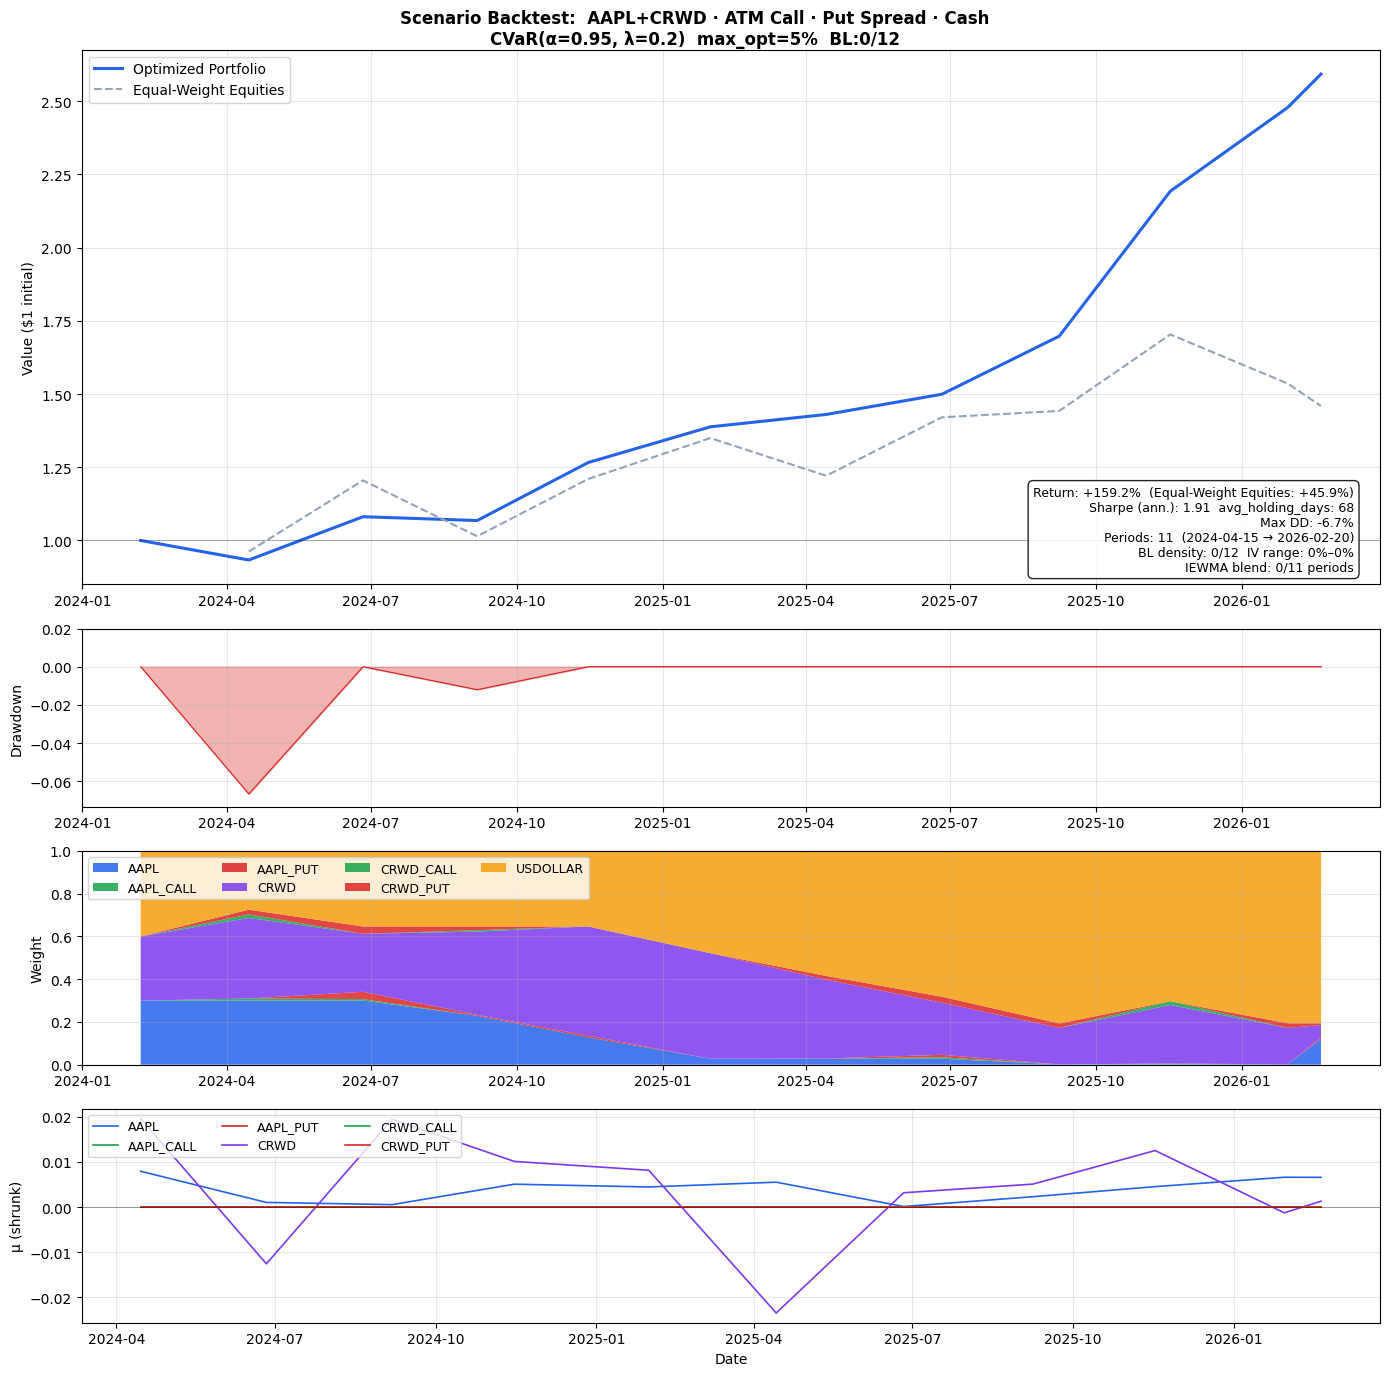

Plot saved: /Users/hakeemshindy/cvx_options/data/processed/backtest_results.png


In [27]:
plot_path = plot_results(portfolio_df, weights_df, returns, mu_df, diag, show=True)
print(f"Plot saved: {plot_path}")